In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [7]:
df = pd.read_csv("../data/synthetic_fraud_dataset.csv")

# Features for the model
X = df[['amount', 'hour', 'device_risk_score', 'ip_risk_score',
        'transaction_type', 'merchant_category', 'country']]

# Target variable
y = df['is_fraud']



In [8]:
# Convert categorical columns into dummy variables
X = pd.get_dummies(X, columns=['transaction_type', 'merchant_category', 'country'], drop_first=True)

print(X.head())

        amount  hour  device_risk_score  ip_risk_score  \
0  4922.587542    12           0.992347       0.947908   
1    48.018303    21           0.168571       0.224057   
2   136.881960    14           0.296127       0.125058   
3    80.534719    23           0.124801       0.159243   
4   120.041158    16           0.098129       0.027542   

   transaction_type_Online  transaction_type_POS  transaction_type_QR  \
0                    False                 False                False   
1                    False                 False                 True   
2                     True                 False                False   
3                    False                  True                False   
4                     True                 False                False   

   merchant_category_Electronics  merchant_category_Food  \
0                          False                   False   
1                          False                    True   
2                          False

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# Columns to scale
numeric_cols = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']

# Create scaler
scaler = StandardScaler()

# Scale training data and testing data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [11]:
# Create and train logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [12]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities for fraud class
y_prob = model.predict_proba(X_test)[:, 1]

In [13]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1900    0]
 [   0  100]]
ROC-AUC Score: 1.0


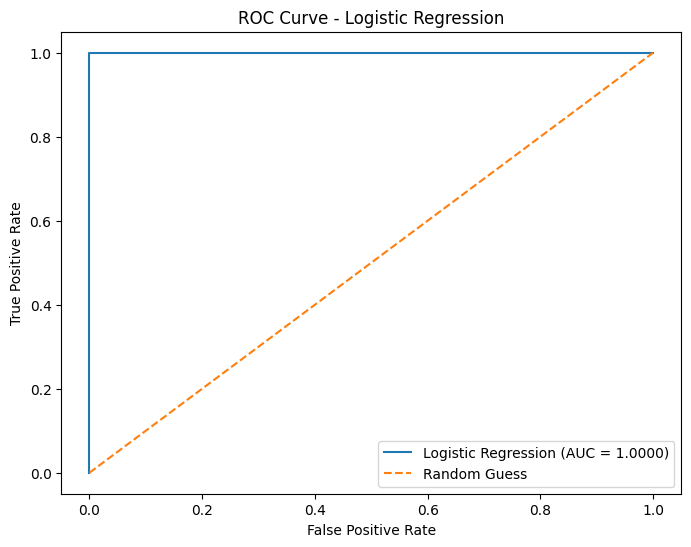

In [14]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

# Financial Fraud Detection Analysis

## Overview

The goal of this project was to analyze transaction data to identify patterns associated with fraudulent activity and to develop a predictive model capable of detecting potentially fraudulent transactions.

Using exploratory data analysis and logistic regression modeling, we examined several factors including:

- Transaction amount
- Transaction type
- Merchant purchase category
- Country of origin
- Time of transaction

The objective was to identify patterns that could help financial institutions detect fraud earlier and reduce financial losses.

---

# Key Findings

## 1. Transaction Amount Patterns

Fraudulent transactions were not evenly distributed across transaction amounts. Certain transaction ranges showed significantly higher fraud rates compared to others.

Lower-value transactions (under $500) were overwhelmingly legitimate, while mid-range transactions showed disproportionately higher fraud activity.

This suggests fraud attempts may cluster around transaction amounts that are large enough to generate meaningful gain but small enough to avoid triggering immediate suspicion.

---

## 2. Transaction Type Risk

Fraud rates varied depending on the transaction type.

Online and remote transactions showed slightly higher fraud rates compared to point-of-sale or ATM transactions.

This pattern is consistent with real-world fraud behavior, as online transactions often involve less physical verification of the user.

---

## 3. Merchant Category Risk

Certain merchant categories were more frequently associated with fraud.

Categories involving easily resold goods (such as electronics or high-value retail items) appeared more frequently in fraudulent transactions.

These categories may be attractive targets for fraud because stolen purchases can quickly be resold.

---

## 4. Geographic Patterns

Fraud occurrences were not evenly distributed across countries.

Some regions produced significantly higher fraud transaction counts compared to others.

This may indicate differences in fraud detection infrastructure, payment processing systems, or organized fraud activity.

---

## 5. Time-Based Fraud Patterns

Fraudulent transactions showed clustering at specific hours of the day.

Higher fraud frequencies appeared during late-night or low-monitoring periods when legitimate users are less likely to notice unusual activity.

---

# Predictive Modeling Results

A logistic regression model was trained to classify transactions as fraudulent or legitimate using the following variables:

- Transaction amount
- Transaction type
- Merchant category
- Country
- Time of transaction
- Device risk score
- IP risk score

The model was evaluated using ROC-AUC to measure its ability to distinguish fraudulent transactions from legitimate ones.

ROC curves demonstrated the model’s ability to detect fraud significantly better than random classification.

---

# Fraud Detection Recommendations

Based on the findings of this analysis, several factors should be considered when flagging potentially fraudulent transactions.

### 1. Transaction Amount Threshold Monitoring
Financial institutions should closely monitor mid-range transaction values that show higher fraud concentrations.

Dynamic thresholds based on user behavior may help detect suspicious activity earlier.

---

### 2. Transaction Type Risk Weighting
Online transactions should be assigned higher risk scores compared to physical transactions.

Additional authentication steps (such as two-factor authentication) may be required for high-risk transaction types.

---

### 3. Merchant Category Risk Scoring
Transactions involving high-risk merchant categories should receive additional scrutiny.

Fraud detection systems should incorporate merchant category risk weighting when calculating fraud probability.

---

### 4. Geographic Risk Monitoring
Transactions originating from regions with historically high fraud activity may require additional verification.

Adaptive geographic risk scoring can improve detection rates.

---

### 5. Time-Based Fraud Detection
Late-night or off-hour transactions may require increased monitoring or secondary authentication if they deviate from typical user behavior.

---

# Conclusion

This analysis identified several important patterns associated with fraudulent transactions, including transaction amount ranges, transaction types, merchant categories, geographic location, and time of occurrence.

By incorporating these variables into fraud detection systems and machine learning models, financial institutions can significantly improve their ability to detect fraudulent activity while minimizing disruptions to legitimate users.
